# Q2 — Filtered Backprojection (FBP)
Ram-Lak, Shepp-Logan, Cosine filters; experiments with L.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import shepp_logan_phantom
from skimage.transform import resize, radon, iradon
from skimage.filters import gaussian

In [2]:
N=128
phantom = resize(shepp_logan_phantom(), (N,N), order=1, anti_aliasing=True)
theta = np.arange(0,180,3)
sinogram = radon(phantom, theta=theta, circle=True)

In [3]:
def myFilter(sinogram, filter_type='ram-lak', L=None):
    proj_len, n_angles = sinogram.shape
    freqs = np.fft.fftfreq(proj_len)
    wmax = np.max(np.abs(freqs))
    if L is None: L = wmax
    H = np.abs(freqs)
    H = np.where(np.abs(freqs) <= L, H, 0.0)
    if filter_type == 'shepp-logan':
        H = H * np.sinc(freqs/(2*L))
    elif filter_type == 'cosine':
        H = H * np.cos(np.pi*freqs/(2*L))
    filtered = np.zeros_like(sinogram)
    for i in range(n_angles):
        P = np.fft.fft(sinogram[:,i])
        P = P * H
        filtered[:,i] = np.real(np.fft.ifft(P))
    return filtered

In [4]:
wmax = np.max(np.abs(np.fft.fftfreq(sinogram.shape[0])))
filters = ['ram-lak', 'shepp-logan', 'cosine']
results = {}
for filt in filters:
    for L in [wmax, wmax/2]:
        fproj = myFilter(sinogram, filter_type=filt, L=L)
        reco = iradon(fproj, theta=theta, filter_name=None, circle=True)
        results[(filt, L)] = reco

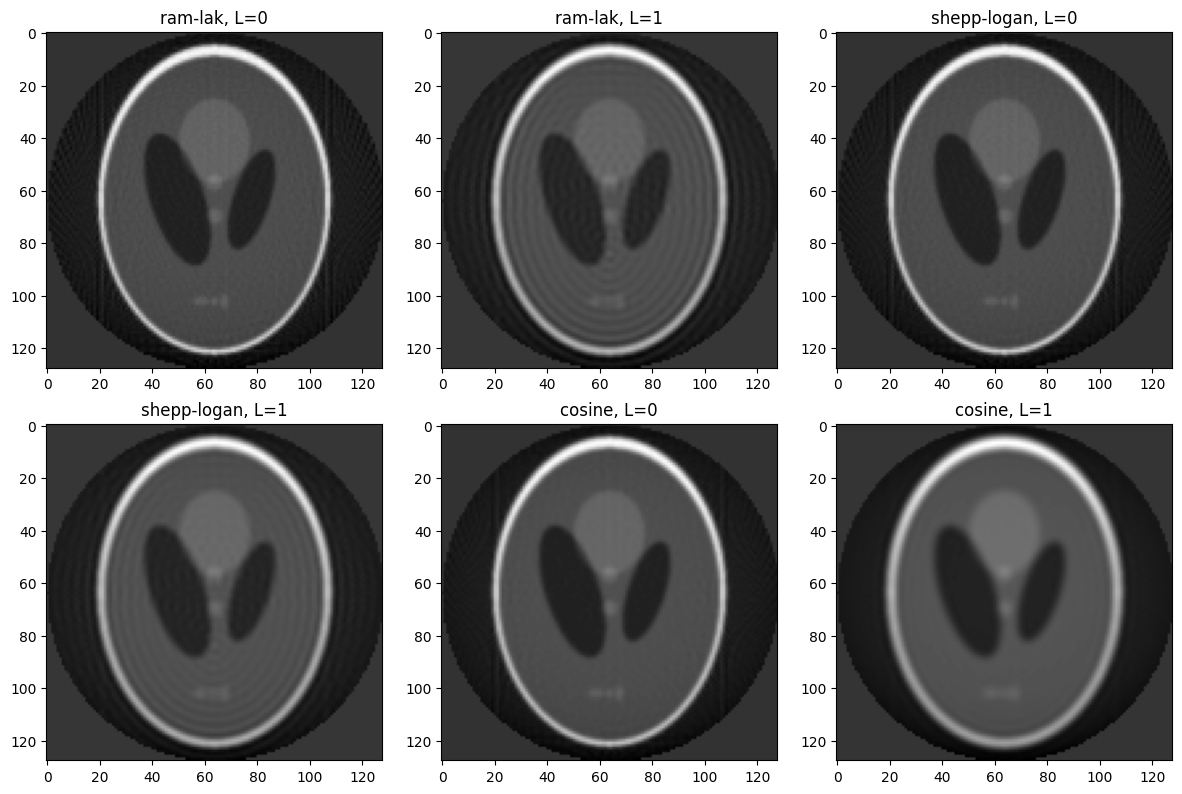

In [5]:
# show results
fig, axs = plt.subplots(2,3, figsize=(12,8))
i=0
for filt in filters:
    for j,L in enumerate([wmax, wmax/2]):
        ax = axs.flatten()[i]
        ax.imshow(results[(filt,L)], cmap='gray')
        ax.set_title(f'{filt}, L={j}')
        i+=1
plt.tight_layout()

In [6]:
# Blur experiments and RRMSE analysis
def rrmse(A,B):
    return np.linalg.norm(A-B)/np.linalg.norm(A)
S0 = phantom
S1 = gaussian(S0, sigma=1, preserve_range=True)
S5 = gaussian(S0, sigma=5, preserve_range=True)
Slist = [S0, S1, S5]
Rlist = []
for S in Slist:
    s = radon(S, theta=theta, circle=True)
    sf = myFilter(s, filter_type='ram-lak', L=wmax)
    R = iradon(sf, theta=theta, filter_name=None, circle=True)
    Rlist.append(R)
errs = [rrmse(Slist[i], Rlist[i]) for i in range(3)]
errs

c:\Users\rishi\Python\Python3119\Lib\site-packages\skimage\transform\radon_transform.py:74: UserWarning: Radon transform: image must be zero outside the reconstruction circle
  warn(


[0.6528851660733128, 0.6611713940228707, 0.7383094386933969]

Text(0, 0.5, 'RRMSE')

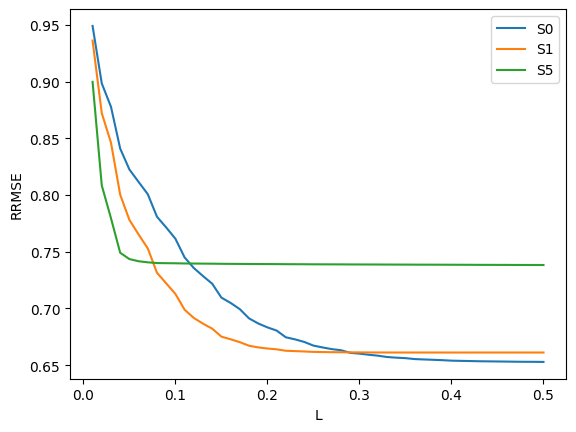

In [7]:
# RRMSE vs L curve
Ls = np.linspace(wmax/50, wmax, 50)
vals = np.zeros((3, len(Ls)))
for k,S in enumerate(Slist):
    s = radon(S, theta=theta, circle=True)
    for i,L in enumerate(Ls):
        sf = myFilter(s, filter_type='ram-lak', L=L)
        R = iradon(sf, theta=theta, filter_name=None, circle=True)
        vals[k,i] = rrmse(S, R)
plt.figure()
for k,label in enumerate(['S0','S1','S5']):
    plt.plot(Ls, vals[k], label=label)
plt.legend(); plt.xlabel('L'); plt.ylabel('RRMSE')

Notes: Ram-Lak is high-pass; Shepp-Logan reduces high-frequency amplification; Cosine tapers high frequencies.